In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
%matplotlib ipympl

import os

# Set to a very large number (e.g., 2^40 or about 1 trillion pixels)
# The value must be passed as a string.
os.environ["OPENCV_IO_MAX_IMAGE_PIXELS"] = str(2**40)

import cv2
import numpy as np
import ezdxf
import matplotlib.pyplot as plt
import math
import metrology_lib as ml
import gc
from PIL import Image

Image.MAX_IMAGE_PIXELS = None


In [3]:
def rotate_massive_image_pil(image_path, angle_deg):
    print("Loading massive image with PIL...")
    # Open the image. PIL lazy-loads, which is great for memory.
    pil_img = Image.open(image_path)
    
    # Force to grayscale ('L' mode) to save RAM if it isn't already
    if pil_img.mode != 'L':
        pil_img = pil_img.convert('L')
        
    print(f"Original shape (Width x Height): {pil_img.size}")
    print("Rotating image (this may take a minute or two)...")
    
    # Perform the rotation.
    # expand=True automatically calculates the new Bounding Box so corners aren't clipped!
    # resample=Image.Resampling.BILINEAR keeps the grid lines smooth.
    rotated_pil = pil_img.rotate(angle_deg, 
                                 resample=Image.Resampling.BILINEAR, 
                                 expand=True, 
                                 fillcolor=0) # 0 = black background
    
    print(f"New expanded shape: {rotated_pil.size}")
    print("Converting back to OpenCV/Numpy format...")
    
    # Convert the PIL image back into a standard NumPy array for OpenCV
    rotated_array = np.array(rotated_pil)
    
    # Clean up memory
    del pil_img
    del rotated_pil
    gc.collect()
    
    return rotated_array

In [4]:
# --- Configuration ---
PATH = "F:/LEM-X/Masks/Metrology/"
IMAGE_PATH = PATH + "grid.bmp"

In [5]:
correction_angle = 0.013289 #Determined from first fit without rotation

# Replace with your actual path
img = rotate_massive_image_pil(IMAGE_PATH, correction_angle)

Loading massive image with PIL...
Original shape (Width x Height): (48588, 48750)
Rotating image (this may take a minute or two)...
New expanded shape: (48600, 48762)
Converting back to OpenCV/Numpy format...


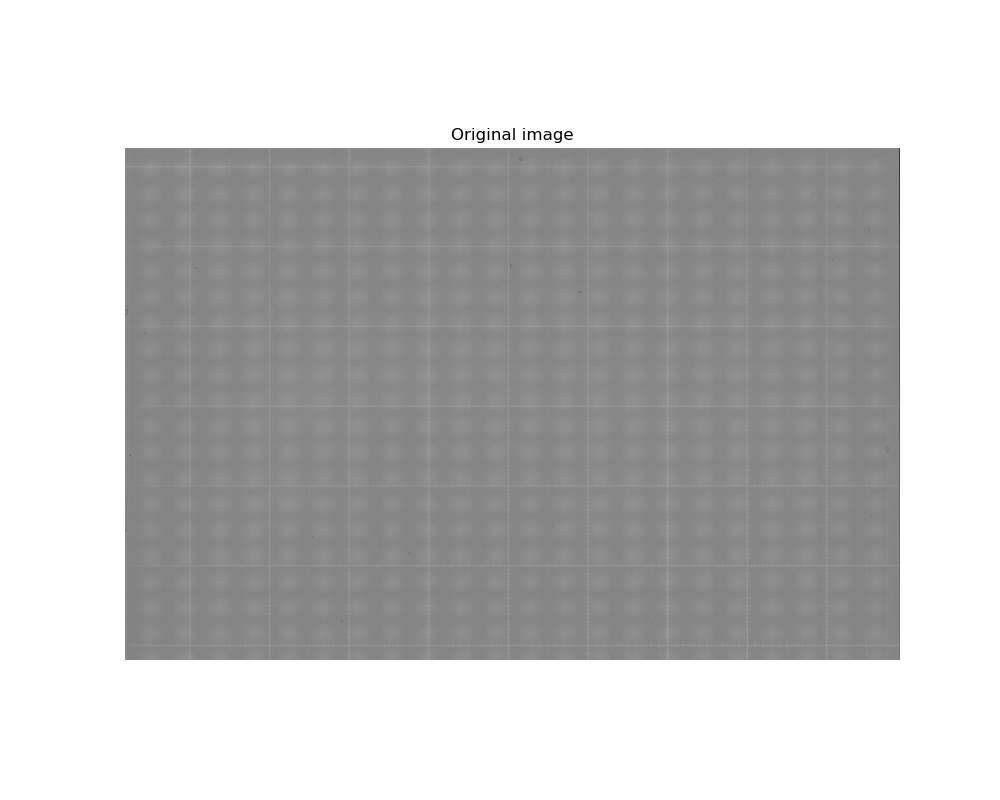

In [6]:
#img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
subimg = img[9200:40000,2000:]
del img
gc.collect()
ml.show_image(subimg, 'Original image', 0.1)

In [7]:
subimg.shape

(30800, 46600)

In [8]:
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(3, 3))
equalized = clahe.apply(subimg)

In [9]:
otsu_fac=2
#blurred = cv2.MedianBlur(equalized, (3, 3), 0)
blurred = cv2.bilateralFilter(equalized, 9,9,9)

_, binary = cv2.threshold(equalized, 0, 255, cv2.THRESH_BINARY + otsu_fac * cv2.THRESH_OTSU)

del equalized
del blurred
gc.collect()

42

In [10]:
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1000, 1))
vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1000))

horizontal_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)
vertical_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)

intersections = cv2.bitwise_and(horizontal_lines, vertical_lines)


Number of grid centers found: 64


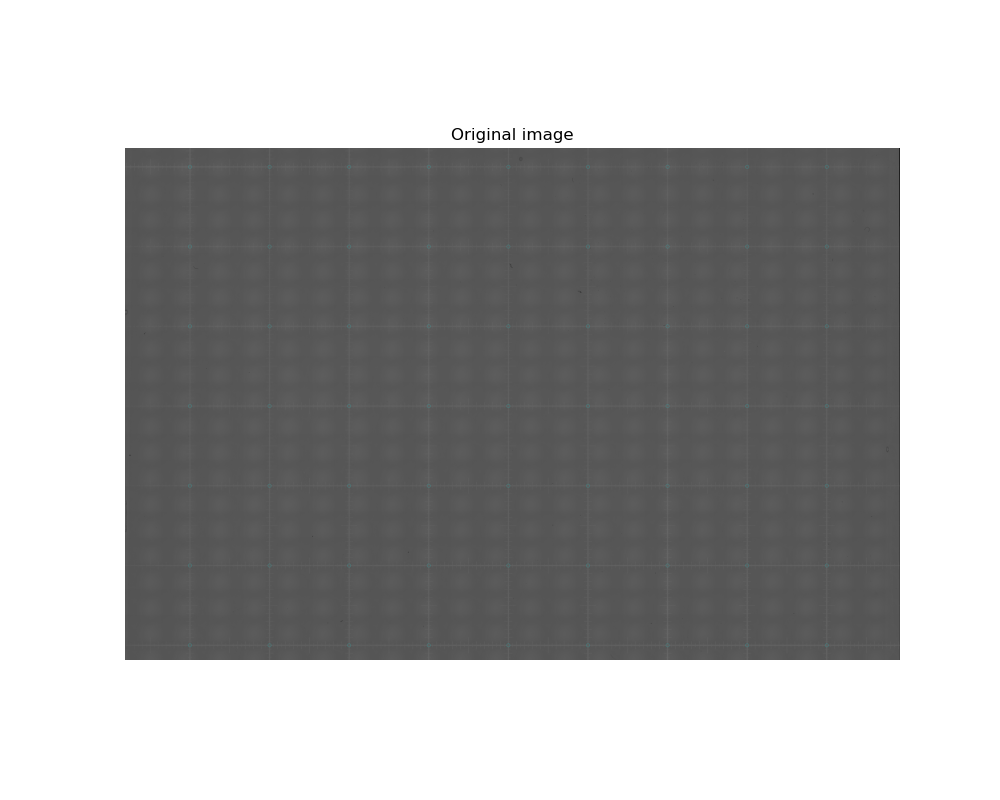

In [11]:


num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(intersections, connectivity=8)

output_img = cv2.cvtColor(subimg, cv2.COLOR_GRAY2BGR)

centers = []
for i in range(1, num_labels):
    # Extract X and Y coordinates
    x, y = centroids[i]
    centers.append((x, y))
    #print(f"Center {i}: (X: {x:.2f}, Y: {y:.2f})")
        
    # Draw a red circle at the center of each detected intersection
    cv2.circle(output_img, (int(x), int(y)), 1, (255, 0, 0), -1)
    cv2.circle(output_img, (int(x), int(y)), 100, (0, 255, 255), 5)

print("Number of grid centers found:", len(centroids))
ml.show_image(output_img, 'Original image', 0.25)

In [12]:
# Assume 'centers' is the list of (x,y) tuples from your previous detection
# Convert it to a numpy array for easier math
centers_array = np.array(centers, dtype=np.float32)

# --- 1. FIND THE ROTATION ANGLE ---
# Isolate horizontal points. Assuming the horizontal line passes near the median Y coordinate.
median_y = np.median(centers_array[:, 1])
y_tolerance = 4000  # pixels of vertical tolerance to group the horizontal line
horizontal_points = centers_array[np.abs(centers_array[:, 1] - median_y) < y_tolerance]

# Fit a line to these horizontal points using OpenCV
# vx, vy is the normalized directional vector. x0, y0 is a point on the line.
vx, vy, x0, y0 = cv2.fitLine(horizontal_points, cv2.DIST_L2, 0, 0.01, 0.01)

# Calculate the angle in radians and degrees
angle_rad = np.arctan2(vy, vx)[0]
angle_deg = np.degrees(angle_rad)
print(f"Detected rotation angle: {angle_deg:.3f} degrees")


# --- 2. ROTATE THE POINTS ---
# Define the rotation matrix to counter-rotate by the detected angle
theta = -angle_rad
cos_t = np.cos(theta)
sin_t = np.sin(theta)
rotation_matrix = np.array([[cos_t, -sin_t], 
                            [sin_t,  cos_t]])

# Set the pivot point for rotation (the center of our fitted line)
origin = np.array([x0[0], y0[0]])

# Apply rotation to all points (subtract origin, rotate, add origin back)
rotated_points = np.dot(centers_array - origin, rotation_matrix.T) + origin


# --- 3. CALCULATE RESOLUTION (Pixels per mm) ---
# Isolate the aligned points back into horizontal and vertical groups
rotated_horizontal = rotated_points[np.abs(rotated_points[:, 1] - origin[1]) < y_tolerance]
rotated_vertical = rotated_points[np.abs(rotated_points[:, 0] - origin[0]) < y_tolerance]

# Sort the coordinates so they are strictly in order from left-to-right and top-to-bottom
sorted_x = np.sort(rotated_horizontal[:, 0])
sorted_y = np.sort(rotated_vertical[:, 1])

# Calculate the pixel distance between adjacent points
# np.diff subtracts each element from the next one (e.g., x[1]-x[0], x[2]-x[1])
diffs_x = np.diff(sorted_x)
diffs_y = np.diff(sorted_y)

# Use the median distance to ignore any "gaps" if a point failed to detect earlier
median_dx_px = np.median(diffs_x)
median_dy_px = np.median(diffs_y)

# Calculate resolution knowing the physical grid is 10mm
grid_size_mm = 10.0
px_per_mm_x = median_dx_px / grid_size_mm
px_per_mm_y = median_dy_px / grid_size_mm

print(f"Median X spacing: {median_dx_px:.2f} pixels")
print(f"Median Y spacing: {median_dy_px:.2f} pixels")
print("-" * 30)
print(f"Resolution X: {px_per_mm_x:.4f} px/mm")
print(f"Resolution Y: {px_per_mm_y:.4f} px/mm")

print(1/px_per_mm_x, 1/px_per_mm_y)

Detected rotation angle: 0.001 degrees
Median X spacing: 4786.00 pixels
Median Y spacing: 4787.50 pixels
------------------------------
Resolution X: 478.6000 px/mm
Resolution Y: 478.7500 px/mm
0.0020894276 0.0020887728


In [13]:
# --- 1. ASSIGN GRID INDICES (m, n) ---
# We use the roughly rotated points and median spacings from the previous step
# to figure out the integer grid position of each detected center.
# We use np.round to snap them to the nearest integer index.
m_indices = np.round((rotated_points[:, 0] - origin[0]) / median_dx_px)
n_indices = np.round((rotated_points[:, 1] - origin[1]) / median_dy_px)

# --- 2. BUILD THE MATRICES FOR LEAST SQUARES ---
# Create the design matrix A containing [m, n, 1] for each point
A = np.column_stack([m_indices, n_indices, np.ones_like(m_indices)])

# Create the target vectors using the ORIGINAL, unrotated pixel coordinates
U = centers_array[:, 0]  # Raw X pixel coordinates
V = centers_array[:, 1]  # Raw Y pixel coordinates

# --- 3. SOLVE THE LEAST SQUARES PROBLEM ---
# np.linalg.lstsq fits all points simultaneously to minimize total error
# We unpack just the solution vectors (the coefficients)
coeffs_X, _, _, _ = np.linalg.lstsq(A, U, rcond=None)
coeffs_Y, _, _, _ = np.linalg.lstsq(A, V, rcond=None)

a, b, c = coeffs_X
d, e, f = coeffs_Y

# --- 4. EXTRACT GLOBAL CALIBRATION PARAMETERS ---
# Vector (a, d) represents the pixel step for 1 grid unit (10 mm) in the X direction
# Vector (b, e) represents the pixel step for 1 grid unit (10 mm) in the Y direction

grid_size_mm = 10.0

# Calculate the precise global resolution (magnitude of the step vectors / 10mm)
res_x_global = np.sqrt(a**2 + d**2) / grid_size_mm
res_y_global = np.sqrt(b**2 + e**2) / grid_size_mm

# Calculate the precise global rotation angle (using the X-axis vector)
angle_rad_global = np.arctan2(d, a)
angle_deg_global = np.degrees(angle_rad_global)

print("-" * 30)
print("GLOBAL LEAST SQUARES FIT RESULTS:")
print(f"Global Rotation angle: {angle_deg_global:.4f} degrees")
print(f"Global Resolution X:   {1/res_x_global*1000:.6f} um/px")
print(f"Global Resolution Y:   {1/res_y_global*1000:.6f} um/px")

# Optional: The point (c, f) is the exact sub-pixel coordinate of your true mathematical origin!
print(f"Fitted Origin (X, Y):  ({c:.2f}, {f:.2f})")

------------------------------
GLOBAL LEAST SQUARES FIT RESULTS:
Global Rotation angle: -0.0003 degrees
Global Resolution X:   2.089288 um/px
Global Resolution Y:   2.088862 um/px
Fitted Origin (X, Y):  (23052.63, 15553.33)


In [14]:
# --- 1. PREDICT THEORETICAL POSITIONS ---
# Multiply our design matrix A by our fitted coefficients to get the ideal grid
U_pred = np.dot(A, coeffs_X)
V_pred = np.dot(A, coeffs_Y)

# --- 2. CALCULATE ERRORS ---
# Calculate the difference in X and Y for every single point
error_X = U - U_pred
error_Y = V - V_pred

# Calculate the Euclidean distance (total pixel error) for each point
# Formula: sqrt(dx^2 + dy^2)
point_errors = np.sqrt(error_X**2 + error_Y**2)

# --- 3. COMPUTE QUALITY METRICS ---
# Calculate Root Mean Square Error (RMSE)
rmse = np.sqrt(np.mean(point_errors**2))

# Find the maximum error and which point caused it
max_error = np.max(point_errors)
worst_point_index = np.argmax(point_errors)
worst_point_coords = (U[worst_point_index], V[worst_point_index])

print("-" * 30)
print("FIT QUALITY METRICS:")
print(f"RMSE:      {rmse:.4f} pixels")
print(f"Max Error: {max_error:.4f} pixels")
print(f"Worst Point Location: (X: {worst_point_coords[0]:.1f}, Y: {worst_point_coords[1]:.1f})")

# --- OPTIONAL: VISUALIZE ERRORS ---
# It's highly recommended to print or plot a histogram of your errors.
# If the max error is huge compared to the RMSE, you have outliers.

------------------------------
FIT QUALITY METRICS:
RMSE:      1.0998 pixels
Max Error: 4.0408 pixels
Worst Point Location: (X: 13480.5, Y: 1195.5)


In [15]:
# --- 1. IDENTIFY OUTLIERS ---
# We use the 3-sigma rule: anything with an error > 3 * RMSE is considered an outlier.
threshold = 2#1.5 * rmse

# Create a boolean mask: True for points we want to KEEP, False for outliers
valid_points_mask = point_errors < threshold

# Count how many points we are about to drop
num_outliers = len(point_errors) - np.sum(valid_points_mask)
print(f"Dropping {num_outliers} outlier(s) with an error > {threshold:.2f} pixels.")


# --- 2. FILTER THE DATA ---
# Apply the boolean mask to our matrices to isolate the good data
A_clean = A[valid_points_mask]
U_clean = U[valid_points_mask]
V_clean = V[valid_points_mask]


# --- 3. RE-FIT THE MODEL (WITH CLEAN DATA) ---
# Run Least Squares again, this time without the outliers skewing the math
coeffs_X_clean, _, _, _ = np.linalg.lstsq(A_clean, U_clean, rcond=None)
coeffs_Y_clean, _, _, _ = np.linalg.lstsq(A_clean, V_clean, rcond=None)

a_c, b_c, c_c = coeffs_X_clean
d_c, e_c, f_c = coeffs_Y_clean


# --- 4. CALCULATE REFINED PARAMETERS & NEW RMSE ---
# Recalculate global resolution and rotation with the clean coefficients
res_x_clean = np.sqrt(a_c**2 + d_c**2) / grid_size_mm
res_y_clean = np.sqrt(b_c**2 + e_c**2) / grid_size_mm
angle_deg_clean = np.degrees(np.arctan2(d_c, a_c))

# Predict the theoretical positions using the clean model to check our new accuracy
U_pred_clean = np.dot(A_clean, coeffs_X_clean)
V_pred_clean = np.dot(A_clean, coeffs_Y_clean)

# Calculate the new RMSE
error_X_clean = U_clean - U_pred_clean
error_Y_clean = V_clean - V_pred_clean
point_errors_clean = np.sqrt(error_X_clean**2 + error_Y_clean**2)
rmse_clean = np.sqrt(np.mean(point_errors_clean**2))


print("-" * 30)
print("REFINED FIT RESULTS (OUTLIERS REMOVED):")
print(f"Refined RMSE:          {rmse_clean:.4f} pixels (was {rmse:.4f})")
print(f"Refined Rotation:      {angle_deg_clean:.6f} degrees")
print(f"Refined Resolution X:  {1/res_x_clean*1000:.8f} um/px")
print(f"Refined Resolution Y:  {1/res_y_clean*1000:.8f} um/px")
print(f"Refined Origin (X, Y): ({c_c:.2f}, {f_c:.2f})")



Dropping 4 outlier(s) with an error > 2.00 pixels.
------------------------------
REFINED FIT RESULTS (OUTLIERS REMOVED):
Refined RMSE:          0.7557 pixels (was 1.0998)
Refined Rotation:      0.000541 degrees
Refined Resolution X:  2.08927321 um/px
Refined Resolution Y:  2.08881140 um/px
Refined Origin (X, Y): (23052.54, 15553.17)


Saved deformation map to 'deformation_map.png'


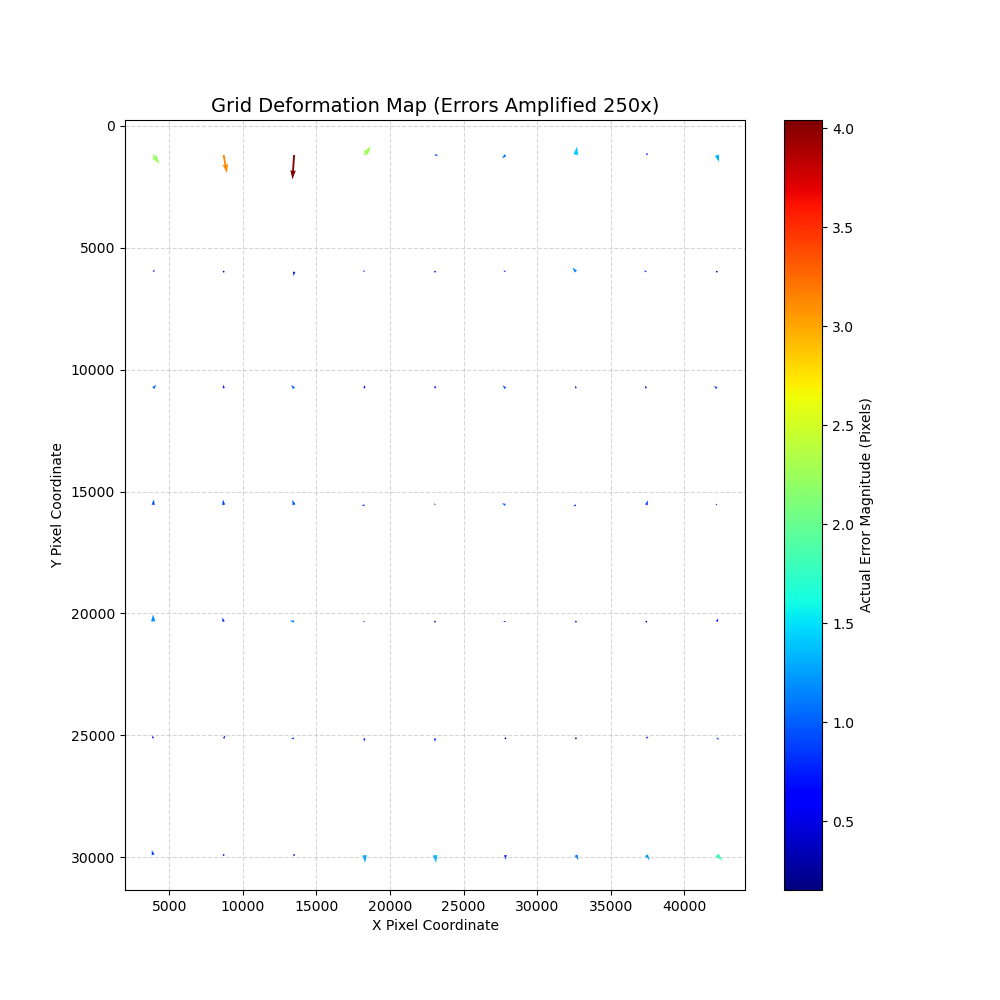

In [16]:
# --- 1. PREPARE THE VECTOR FIELD (QUIVER PLOT) ---
# We use the predicted (ideal) coordinates as the base of our arrows
X_base = U_pred
Y_base = V_pred

# The direction and length of the arrows are the errors we calculated
# We multiply by an amplification factor so tiny sub-pixel errors are visible to the human eye
amplification = 250  
U_dir = error_X * amplification
V_dir = error_Y * amplification

# Color code the arrows by their error magnitude (larger errors = red, smaller = blue)
error_magnitudes = np.sqrt(error_X**2 + error_Y**2)

# --- 2. PLOT THE DEFORMATION MAP ---
plt.figure(figsize=(10, 10))
plt.title(f"Grid Deformation Map (Errors Amplified {amplification}x)", fontsize=14)

# Draw the vector arrows
quiver = plt.quiver(X_base, Y_base, U_dir, V_dir, error_magnitudes, 
                    angles='xy', scale_units='xy', scale=1, cmap='jet', width=0.003)

# Invert Y axis because image coordinates start (0,0) at the top-left
plt.gca().invert_yaxis()

plt.colorbar(quiver, label='Actual Error Magnitude (Pixels)')
plt.xlabel("X Pixel Coordinate")
plt.ylabel("Y Pixel Coordinate")
plt.grid(True, linestyle='--', alpha=0.5)

# Save and show
plt.savefig('deformation_map.png', dpi=1200)
print("Saved deformation map to 'deformation_map.png'")
plt.show()